In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [17]:
df = pd.read_csv('Supermart.csv.csv')

print(f"✅ Dataset loaded!")
print(f"   Total rows    : {len(df):,}")
print(f"   Total columns : {len(df.columns)}")

✅ Dataset loaded!
   Total rows    : 9,994
   Total columns : 11


In [20]:
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [21]:
df.tail()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
9989,OD9990,Sudeep,"Eggs, Meat & Fish",Eggs,Madurai,12/24/2015,West,945,0.16,359.10,Tamil Nadu
9990,OD9991,Alan,Bakery,Biscuits,Kanyakumari,07-12-2015,West,1195,0.26,71.70,Tamil Nadu
9991,OD9992,Ravi,Food Grains,Rice,Bodi,06-06-2017,West,1567,0.16,501.44,Tamil Nadu
9992,OD9993,Peer,Oil & Masala,Spices,Pudukottai,10/16/2018,West,1659,0.15,597.24,Tamil Nadu
9993,OD9994,Ganesh,Food Grains,Atta & Flour,Tirunelveli,4/17/2018,West,1034,0.28,165.44,Tamil Nadu


In [6]:
print("Column Names:")
for col in df.columns:
    print(f"  - {col} ({df[col].dtype})")

Column Names:
  - Order ID (object)
  - Customer Name (object)
  - Category (object)
  - Sub Category (object)
  - City (object)
  - Order Date (object)
  - Region (object)
  - Sales (int64)
  - Discount (float64)
  - Profit (float64)
  - State (object)


In [7]:
print("Missing Values in Each Column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values in Each Column:
Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

Total missing values: 0


In [8]:
# Convert 'Order Date' from text to a proper date format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')

# Remove rows where date couldn't be parsed
df = df.dropna(subset=['Order Date'])

# Add new columns we'll use in analysis
df['Year']  = df['Order Date'].dt.year.astype(int)
df['Month'] = df['Order Date'].dt.month
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

print("✅ Data cleaned!")
print(f"   Date range : {df['Order Date'].min().date()}  →  {df['Order Date'].max().date()}")
print(f"   Years in data : {sorted(df['Year'].unique())}")
df[['Order Date', 'Year', 'Month', 'Profit Margin %']].head()

✅ Data cleaned!
   Date range : 2015-01-02  →  2018-12-11
   Years in data : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


,Order Date,Year,Month,Profit Margin %
0,2017-08-11,2017,8,32.0
1,2017-08-11,2017,8,20.0
2,2017-12-06,2017,12,7.0
3,2016-11-10,2016,11,10.0
4,2016-11-10,2016,11,39.0


In [9]:
print("=" * 40)
print("   BUSINESS SUMMARY")
print("=" * 40)
print(f"  Total Revenue    : Rs. {df['Sales'].sum():>12,.0f}")
print(f"  Total Profit     : Rs. {df['Profit'].sum():>12,.0f}")
print(f"  Total Orders     :     {len(df):>12,}")
print(f"  Avg Order Value  : Rs. {df['Sales'].mean():>12,.0f}")
print(f"  Avg Profit Margin:     {df['Profit Margin %'].mean():>11.2f}%")
print(f"  Avg Discount     :     {df['Discount'].mean()*100:>11.1f}%")
print("=" * 40)

   BUSINESS SUMMARY
  Total Revenue    : Rs.    6,053,500
  Total Profit     : Rs.    1,503,059
  Total Orders     :            4,042
  Avg Order Value  : Rs.        1,498
  Avg Profit Margin:           24.77%
  Avg Discount     :            22.6%


In [10]:
# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print("Sales by Category:")
print("-" * 35)
for cat, sales in category_sales.items():
    print(f"  {cat:<25} Rs. {sales:>10,.0f}")

Sales by Category:
-----------------------------------
  Eggs, Meat & Fish         Rs.    948,304
  Snacks                    Rs.    910,849
  Fruits & Veggies          Rs.    877,861
  Bakery                    Rs.    869,538
  Food Grains               Rs.    833,326
  Oil & Masala              Rs.    833,099
  Beverages                 Rs.    780,523


In [11]:
# Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print("Sales by Region:")
print("-" * 35)
for region, sales in region_sales.items():
    print(f"  {region:<20} Rs. {sales:>10,.0f}")

Sales by Region:
-----------------------------------
  West                 Rs.  1,905,212
  East                 Rs.  1,755,263
  Central              Rs.  1,419,251
  South                Rs.    972,520
  North                Rs.      1,254


In [12]:
# Yearly Sales
yearly_sales = df.groupby('Year')['Sales'].sum()

print("Yearly Sales:")
print("-" * 30)
for year, sales in yearly_sales.items():
    print(f"  {year}   Rs. {sales:>10,.0f}")

Yearly Sales:
------------------------------
  2015   Rs.  1,200,655
  2016   Rs.  1,236,970
  2017   Rs.  1,611,269
  2018   Rs.  2,004,606


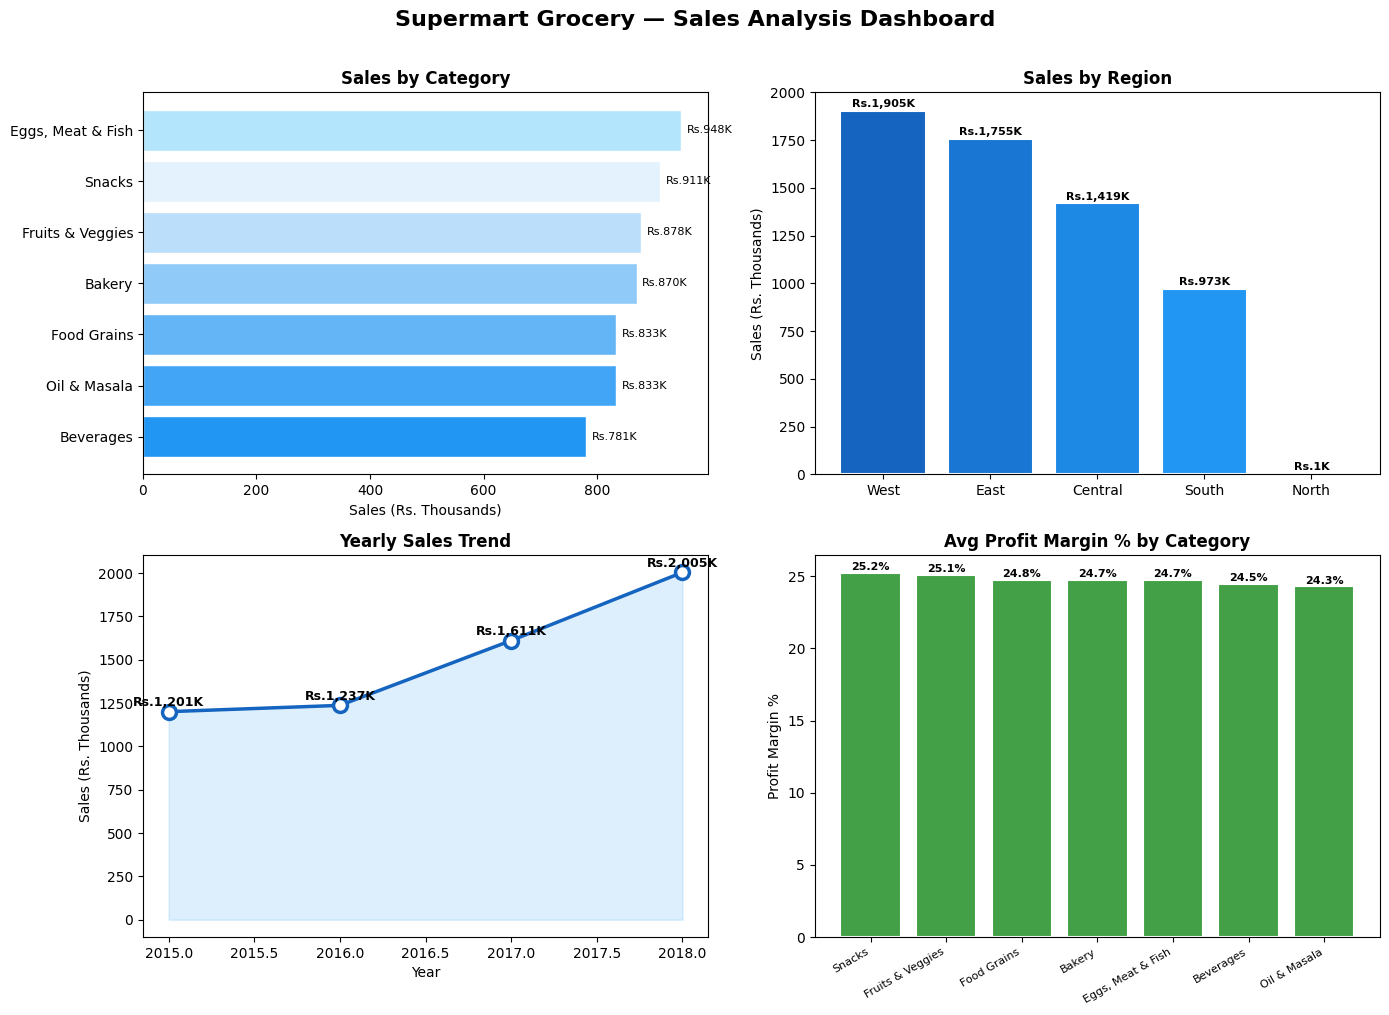

✅ Chart saved as 'sales_dashboard.png'


In [13]:
# ── Create a dashboard with 4 charts in one figure ──

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Supermart Grocery — Sales Analysis Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# ── Chart 1: Sales by Category (Horizontal Bar) ──
category_sales = df.groupby('Category')['Sales'].sum().sort_values()
colors1 = ['#2196F3', '#42A5F5', '#64B5F6', '#90CAF9',
           '#BBDEFB', '#E3F2FD', '#B3E5FC']
axes[0,0].barh(category_sales.index, category_sales.values / 1000,
               color=colors1, edgecolor='white')
axes[0,0].set_title('Sales by Category', fontweight='bold', fontsize=12)
axes[0,0].set_xlabel('Sales (Rs. Thousands)')
for i, val in enumerate(category_sales.values / 1000):
    axes[0,0].text(val + 10, i, f'Rs.{val:,.0f}K', va='center', fontsize=8)

# ── Chart 2: Sales by Region (Bar chart) ──
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
colors2 = ['#1565C0', '#1976D2', '#1E88E5', '#2196F3', '#42A5F5']
bars = axes[0,1].bar(region_sales.index, region_sales.values / 1000,
                     color=colors2, edgecolor='white', linewidth=1.5)
axes[0,1].set_title('Sales by Region', fontweight='bold', fontsize=12)
axes[0,1].set_ylabel('Sales (Rs. Thousands)')
for bar, val in zip(bars, region_sales.values / 1000):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                   f'Rs.{val:,.0f}K', ha='center', fontsize=8, fontweight='bold')

# ── Chart 3: Yearly Sales Trend (Line chart) ──
yearly = df.groupby('Year')['Sales'].sum()
axes[1,0].plot(yearly.index, yearly.values / 1000,
               marker='o', color='#1565C0', linewidth=2.5,
               markersize=10, markerfacecolor='white', markeredgewidth=2.5)
axes[1,0].fill_between(yearly.index, yearly.values / 1000, alpha=0.15, color='#2196F3')
axes[1,0].set_title('Yearly Sales Trend', fontweight='bold', fontsize=12)
axes[1,0].set_ylabel('Sales (Rs. Thousands)')
axes[1,0].set_xlabel('Year')
for x, y in zip(yearly.index, yearly.values / 1000):
    axes[1,0].text(x, y + 30, f'Rs.{y:,.0f}K', ha='center', fontsize=9, fontweight='bold')

# ── Chart 4: Profit Margin by Category (Bar chart) ──
margin = df.groupby('Category')['Profit Margin %'].mean().sort_values(ascending=False)
colors4 = ['#43A047' if v > 15 else '#FB8C00' if v > 10 else '#E53935'
           for v in margin.values]
bars2 = axes[1,1].bar(range(len(margin)), margin.values,
                      color=colors4, edgecolor='white', linewidth=1.5)
axes[1,1].set_title('Avg Profit Margin % by Category', fontweight='bold', fontsize=12)
axes[1,1].set_ylabel('Profit Margin %')
axes[1,1].set_xticks(range(len(margin)))
axes[1,1].set_xticklabels(margin.index, rotation=30, ha='right', fontsize=8)
for bar, val in zip(bars2, margin.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                   f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('sales_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'sales_dashboard.png'")

In [14]:
top_cat    = df.groupby('Category')['Sales'].sum().idxmax()
top_region = df.groupby('Region')['Sales'].sum().idxmax()
best_margin_cat = df.groupby('Category')['Profit Margin %'].mean().idxmax()
worst_margin_cat = df.groupby('Category')['Profit Margin %'].mean().idxmin()
total_rev = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("=" * 50)
print("   KEY FINDINGS FROM THE ANALYSIS")
print("=" * 50)
print(f"  1. Best selling category  : {top_cat}")
print(f"  2. Top performing region  : {top_region}")
print(f"  3. Highest profit margin  : {best_margin_cat}")
print(f"  4. Lowest profit margin   : {worst_margin_cat}")
print(f"  5. Overall profit margin  : {(total_profit/total_rev*100):.1f}%")
print(f"  6. Total revenue          : Rs. {total_rev:,.0f}")
print(f"  7. Total profit           : Rs. {total_profit:,.0f}")
print("=" * 50)
print()
print("RECOMMENDATIONS:")
print(f"  → Focus marketing on '{top_cat}' — highest sales")
print(f"  → Expand operations in '{top_region}' — best region")
print(f"  → Review discounts on '{worst_margin_cat}' — lowest margin")

   KEY FINDINGS FROM THE ANALYSIS
  1. Best selling category  : Eggs, Meat & Fish
  2. Top performing region  : West
  3. Highest profit margin  : Snacks
  4. Lowest profit margin   : Oil & Masala
  5. Overall profit margin  : 24.8%
  6. Total revenue          : Rs. 6,053,500
  7. Total profit           : Rs. 1,503,059

RECOMMENDATIONS:
  → Focus marketing on 'Eggs, Meat & Fish' — highest sales
  → Expand operations in 'West' — best region
  → Review discounts on 'Oil & Masala' — lowest margin
